# Business Problem

An e-commerce site is testing a **new checkout page** to see if it improves user behavior.  
Currently, the site’s conversion rate (percentage of visitors completing a purchase) could be higher.  

The goal of this analysis is to use **A/B testing** to compare the new checkout page (Variant B) with the existing page (Variant A) and determine if it leads to **better conversion performance**.  


# Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest 
import statsmodels.api as sm
import statsmodels.formula.api as smf


from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import seasonal_decompose


# Data Description

The dataset used for this A/B testing project contains 294,481 user records from an e-commerce site. It includes data on which checkout page variant each user saw and whether they converted.

### Columns

1. user_id       : Unique identifier for each user  
2. group         : Indicates the variant assigned to the user (control → original checkout page, treatment → new checkout page)  
3. landing_page  : The checkout page shown to the user (old_page → original checkout page, new_page → new checkout page)  
4. converted     : Indicates whether the user completed a purchase (0 → did not convert, 1 → converted)  
5. timestamp     : Date and time when the user visited the site  

# Data check

In [6]:
df = pd.read_csv('Dataset/ab_data.csv')

In [7]:
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1


In [9]:
df.shape

(294480, 5)

In [10]:
df.dtypes

user_id          int64
timestamp       object
group           object
landing_page    object
converted        int64
dtype: object

In [15]:
df['group'].value_counts()

group
treatment    147278
control      147202
Name: count, dtype: int64

In [16]:
df['converted'].value_counts()

converted
0    259243
1     35237
Name: count, dtype: int64

In [17]:
df['landing_page'].value_counts()

landing_page
new_page    147241
old_page    147239
Name: count, dtype: int64

In [18]:
# remove inconsistencys
df = df[((df['group'] == 'control') & (df['landing_page'] == 'old_page')) |
                  ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))]


In [20]:
# cheking duplicates 
df['user_id'].duplicated().sum()


np.int64(2)

In [22]:
# See the duplicate rows
df[df['user_id'].duplicated(keep=False)]

,user_id,timestamp,group,landing_page,converted
1899,773192,37:58.8,treatment,new_page,0
2893,773192,55:59.6,treatment,new_page,0
250001,759899,07:36.1,treatment,new_page,0
294478,759899,20:29.0,treatment,new_page,0


In [23]:
# keeping the first occurance
df = df.drop_duplicates(subset='user_id', keep='first')
df[df['user_id'].duplicated(keep=False)]

,user_id,timestamp,group,landing_page,converted


# Calculaiting matrics

In [27]:
conversion_rates = df.groupby('group')['converted'].mean()
print(conversion_rates)

group
control      0.120386
treatment    0.118807
Name: converted, dtype: float64


In [28]:
diff = conversion_rates['treatment'] - conversion_rates['control']
print(diff)

-0.0015790565976871451


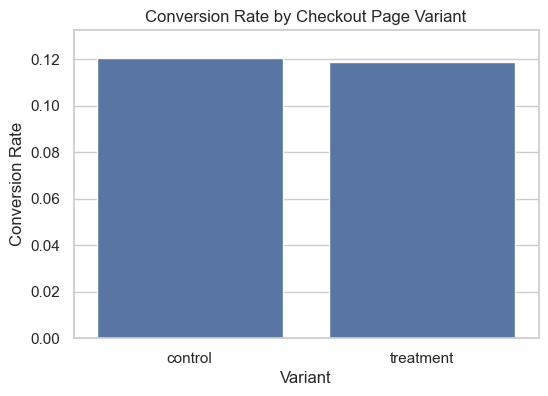

In [29]:
plt.figure(figsize=(6,4))
sns.barplot(x=conversion_rates.index, y=conversion_rates.values)
plt.title('Conversion Rate by Checkout Page Variant')
plt.ylabel('Conversion Rate')
plt.xlabel('Variant')
plt.ylim(0, max(conversion_rates.values)*1.1)
plt.show()


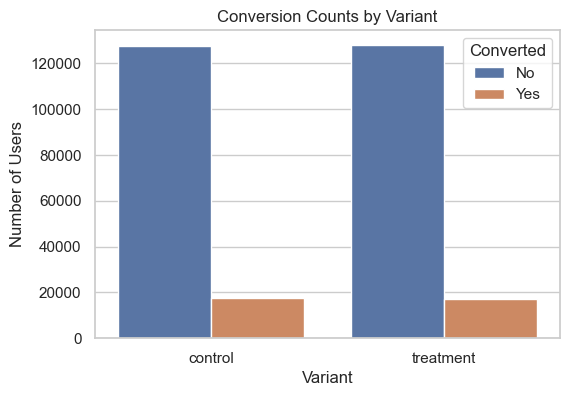

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(x='group', hue='converted', data=df)
plt.title('Conversion Counts by Variant')
plt.xlabel('Variant')
plt.ylabel('Number of Users')
plt.legend(title='Converted', labels=['No', 'Yes'])
plt.show()



The bar chart shows the number of users who converted or did not convert for each variant:
- X-axis: Variant (control = original page, treatment = new page)  
- Y-axis: Number of users  
- Blue: Users who did not convert  
- Orange: Users who converted  

**Key Observations:**  
- Total users are similar for both variants (~125,000 each)  
- Control group had slightly more conversions than treatment
- Overall conversion rate is low, and the treatment variant did not outperform the control



# Statistical Testing

In [35]:
count = np.array([df[df['group'] == 'treatment']['converted'].sum(),
                 df[df['group'] == 'control']['converted'].sum()])
nobs = np.array([df[df['group'] == 'treatment'].shape[0],
               df[df['group'] == 'control'].shape[0]])

stat , pval = proportions_ztest(count, nobs)
print('Z-test statistic:' ,stat)
print('p-value',pval)

Z-test statistic: -1.3116075339133115
p-value 0.18965258971881804


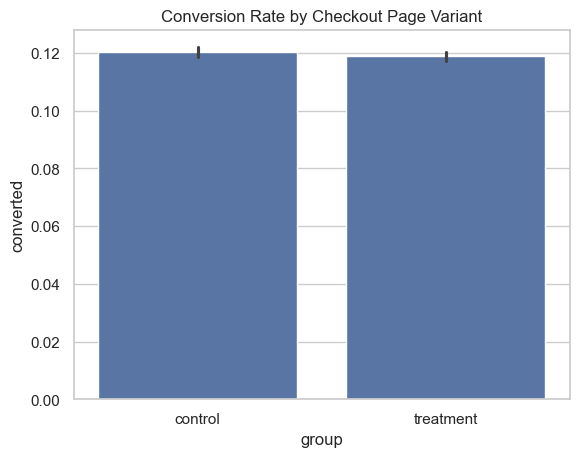

In [39]:
sns.barplot(x='group', y='converted', data=df)
plt.title('Conversion Rate by Checkout Page Variant')
plt.show()


We performed a z-test to determine if the difference in conversion rates between the control and treatment variants is statistically significant.

Results: 
- Z-test statistic: -1.31  
- p-value: 0.1897  

Interpretation:
- The negative Z-statistic indicates that the treatment variant had a slightly lower conversion rate than the control.  
- The p-value (0.1897) is greater than the typical significance level of 0.05, meaning the difference is not statistically significant 
*Business Conclusion: 
- There is no evidence that the new checkout page improves conversion rates.  
- The observed difference could be due to random chance.  
- Recommendation: The company may choose **not to implement the new page**, or consider **further testing with changes** before a full rollout.
